In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from xgboost import XGBClassifier

import seaborn as sns
import matplotlib.pyplot as plt

import joblib

import warnings
warnings.filterwarnings("ignore")

In [14]:
df = pd.read_csv("thalassemia_transfusion_dataset_balanced_units.csv")

df.head()

,patient_id,age,gender,weight_kg,thalassemia_type,current_hb_level,target_hb_level,ferritin_level,days_since_last_transfusion,previous_units_received,average_units_per_transfusion,transfusions_last_12_months,spleen_status,symptom_severity,blood_group,predicted_units_required
0,P00001,6,Female,17.3,Major,9.4,9.2,3830,45,4,1.4,21,Normal,Mild,AB+,1
1,P00002,40,Female,68.1,Intermedia,6.8,10.1,4156,20,3,3.3,14,Normal,Severe,B-,3
2,P00003,35,Female,65.8,Major,7.9,9.3,3750,25,4,2.0,23,Normal,Moderate,O+,3
3,P00004,24,Male,43.1,Major,8.7,9.9,3531,10,2,3.5,19,Enlarged,Mild,O+,2
4,P00005,13,Female,21.7,Major,7.8,10.6,3556,20,4,2.4,17,Enlarged,Mild,O+,2


In [15]:
print(df.shape)

df.info()

df.isnull().sum()

(5000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   patient_id                     5000 non-null   object 
 1   age                            5000 non-null   int64  
 2   gender                         5000 non-null   object 
 3   weight_kg                      5000 non-null   float64
 4   thalassemia_type               5000 non-null   object 
 5   current_hb_level               5000 non-null   float64
 6   target_hb_level                5000 non-null   float64
 7   ferritin_level                 5000 non-null   int64  
 8   days_since_last_transfusion    5000 non-null   int64  
 9   previous_units_received        5000 non-null   int64  
 10  average_units_per_transfusion  5000 non-null   float64
 11  transfusions_last_12_months    5000 non-null   int64  
 12  spleen_status                  5000 n

,0
patient_id,0
age,0
gender,0
weight_kg,0
thalassemia_type,0
current_hb_level,0
target_hb_level,0
ferritin_level,0
days_since_last_transfusion,0
previous_units_received,0


In [16]:
categorical_cols = [
    "gender",
    "thalassemia_type",
    "spleen_status",
    "symptom_severity",
    "blood_group"
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [17]:
X = df.drop(
    ["patient_id", "predicted_units_required"],
    axis=1
)

y = df["predicted_units_required"]

In [18]:
y = df["predicted_units_required"] - 1

In [19]:
print(sorted(y.unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    random_state=42
)

In [22]:
param_dist = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [3, 5, 7, 10],

    "learning_rate": [0.01, 0.05, 0.1, 0.2],

    "subsample": [0.7, 0.8, 0.9, 1.0],

    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],

    "min_child_weight": [1, 3, 5],

    "gamma": [0, 0.1, 0.3, 0.5]
}

In [23]:
random_search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=param_dist,

    n_iter=20,

    scoring="f1_weighted",

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_con...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_class=4, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='f1_weighted', verbose=2)

In [24]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 0.8}

Best CV Score:
0.9392962637665361


In [25]:
best_model = random_search.best_estimator_

In [26]:
y_pred = best_model.predict(X_test)

# Convert back to original classes
y_pred_units = y_pred + 1

In [27]:
y_test_units = y_test + 1

In [28]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:",
      accuracy_score(y_test_units, y_pred_units))

print(classification_report(
    y_test_units,
    y_pred_units
))

Accuracy: 0.942
              precision    recall  f1-score   support

           1       0.95      0.92      0.94       180
           2       0.90      0.92      0.91       240
           3       0.94      0.94      0.94       280
           4       0.98      0.98      0.98       300

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



In [29]:
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test)

# Convert back to original classes
y_pred_units = y_pred + 1
y_test_units = y_test + 1

print(
    classification_report(
        y_test_units,
        y_pred_units
    )
)

              precision    recall  f1-score   support

           1       0.95      0.92      0.94       180
           2       0.90      0.92      0.91       240
           3       0.94      0.94      0.94       280
           4       0.98      0.98      0.98       300

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



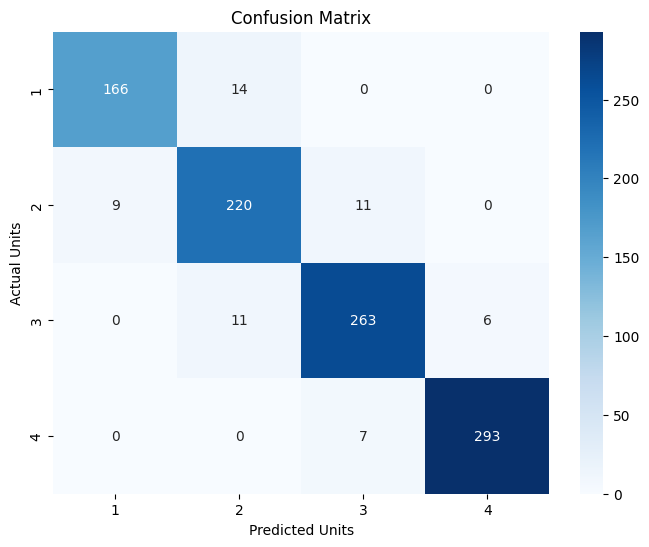

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_units,
    y_pred_units
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1, 2, 3, 4],
    yticklabels=[1, 2, 3, 4]
)

plt.xlabel("Predicted Units")
plt.ylabel("Actual Units")
plt.title("Confusion Matrix")

plt.show()

In [31]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                          Feature  Importance
2                current_hb_level    0.236604
14        symptom_severity_Severe    0.204943
10         thalassemia_type_Major    0.102429
13      symptom_severity_Moderate    0.090911
3                 target_hb_level    0.060171
5     days_since_last_transfusion    0.040994
4                  ferritin_level    0.036523
1                       weight_kg    0.029344
0                             age    0.023239
8     transfusions_last_12_months    0.021935
15                 blood_group_A-    0.020393
21                 blood_group_O-    0.019340
19                 blood_group_B-    0.017278
7   average_units_per_transfusion    0.012333
9                     gender_Male    0.011767


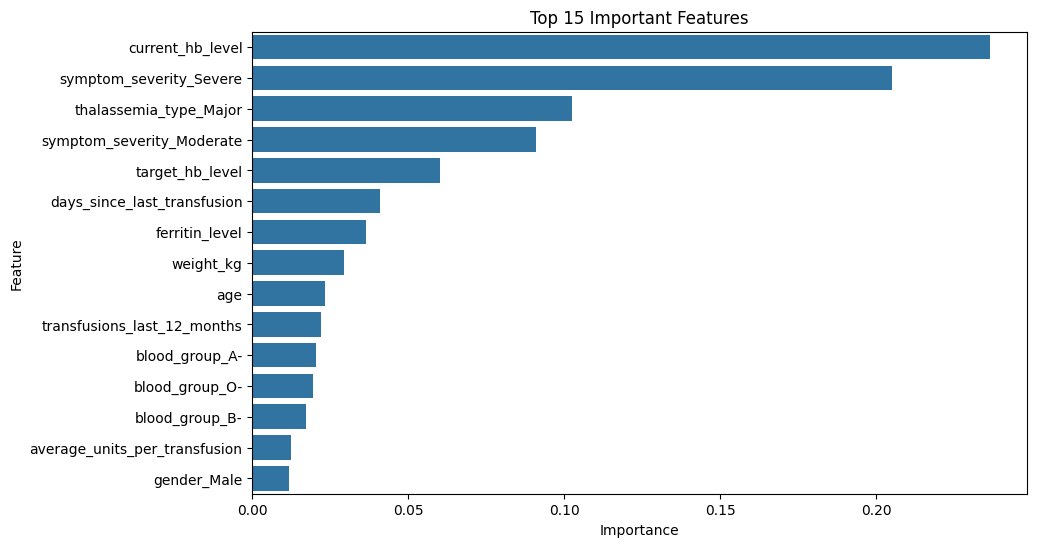

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Important Features"
)

plt.show()

In [33]:
import json

sample_request = {
    "age": 15,
    "gender": "Male",
    "weight_kg": 40,
    "thalassemia_type": "Major",
    "current_hb_level": 7.2,
    "target_hb_level": 10.0,
    "ferritin_level": 1800,
    "days_since_last_transfusion": 25,
    "previous_units_received": 2,
    "average_units_per_transfusion": 2.5,
    "transfusions_last_12_months": 18,
    "spleen_status": "Enlarged",
    "symptom_severity": "Moderate",
    "blood_group": "B+"
}

with open("sample_request.json", "w") as f:
    json.dump(sample_request, f, indent=4)

print("sample_request.json created")

sample_request.json created


In [34]:
from google.colab import files

files.download("sample_request.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
import json

with open("best_params.json", "w") as f:
    json.dump(random_search.best_params_, f, indent=4)

files.download("best_params.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
metadata = {
    "model_type": "XGBoost Multiclass",
    "target": "predicted_units_required",
    "classes": [1, 2, 3, 4],
    "best_cv_score": float(random_search.best_score_)
}

with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

files.download("model_metadata.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
import joblib

joblib.dump(best_model, "thalassemia_units_xgboost.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

files.download("thalassemia_units_xgboost.pkl")
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
!pip freeze > requirements.txt

files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>